# THE AUTO-REGRESSION MODEL 

### Autocorrelation: The Past Influences the Present

The autoregressive model describes a relationship between the present of a variable 
and its past. It is therefore suitable for variables in which the past and present values 
correlate.


In [1]:
import pandas as pd

# Import the dataframe
eq = pd.read_csv('../database/earthquake.csv')
# Describe the dataframe
eq.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


In [2]:
# # Import the pandas profiling package
# from ydata_profiling import ProfileReport

# profile = ProfileReport(eq, title="Earthquake data Profiling Report")
# profile

In [3]:
eq

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.2460,145.6160,Earthquake,131.60,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.8630,127.3520,Earthquake,80.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.5790,-173.9720,Earthquake,20.00,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.0760,-23.5570,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.9380,126.4270,Earthquake,15.00,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,08:22:12,38.3917,-118.8941,Earthquake,12.30,1.2,40.0,5.6,ML,...,18.0,42.47,0.120,NaN,0.1898,NN00570710,NN,NN,NN,Reviewed
23408,12/28/2016,09:13:47,38.3777,-118.8957,Earthquake,8.80,2.0,33.0,5.5,ML,...,18.0,48.58,0.129,NaN,0.2187,NN00570744,NN,NN,NN,Reviewed
23409,12/28/2016,12:38:51,36.9179,140.4262,Earthquake,10.00,1.8,NaN,5.9,MWW,...,NaN,91.00,0.992,4.8,1.5200,US10007NAF,US,US,US,Reviewed
23410,12/29/2016,22:30:19,-9.0283,118.6639,Earthquake,79.00,1.8,NaN,6.3,MWW,...,NaN,26.00,3.553,6.0,1.4300,US10007NL0,US,US,US,Reviewed


In [4]:
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [5]:
# Convert years to dates
eq['year'] = pd.to_datetime(eq['Date'],errors='coerce')

In [6]:
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date                        23412 non-null  object        
 1   Time                        23412 non-null  object        
 2   Latitude                    23412 non-null  float64       
 3   Longitude                   23412 non-null  float64       
 4   Type                        23412 non-null  object        
 5   Depth                       23412 non-null  float64       
 6   Depth Error                 4461 non-null   float64       
 7   Depth Seismic Stations      7097 non-null   float64       
 8   Magnitude                   23412 non-null  float64       
 9   Magnitude Type              23409 non-null  object        
 10  Magnitude Error             327 non-null    float64       
 11  Magnitude Seismic Stations  2564 non-null   float64   

In [7]:
eq['year']=eq['year'].dt.year

In [8]:
eq.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,year
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,1965.0
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,1965.0
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,1965.0
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,1965.0
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,1965.0


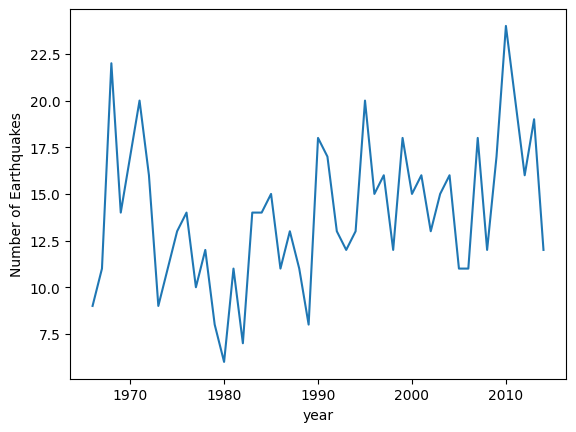

In [9]:
# Convert the earthquake data to the yearly number of earthquakes

import matplotlib.pyplot as plt
# Filter on earthquakes with magnitude of 7 or higher
eq = eq[eq['Magnitude'] >= 7]
# Compute a count of earthquakes per year
earthquakes_per_year = eq.groupby('year').count()
# Remove erroneous values for year
earthquakes_per_year = earthquakes_per_year.iloc[1:-2, 0]
# Make a plot of earthquakes per year
ax = earthquakes_per_year.plot()
ax.set_ylabel("Number of Earthquakes")
plt.show()

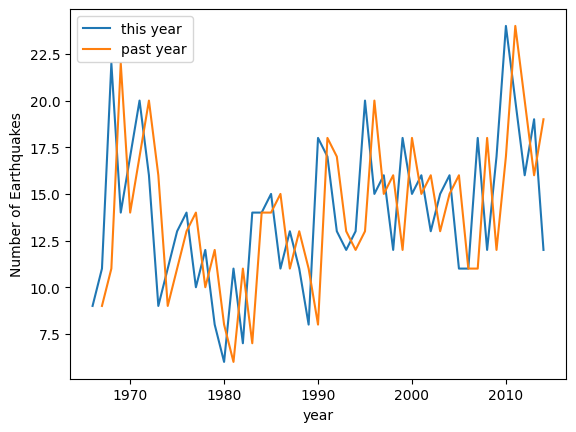

In [10]:
# Plotting the shifted data

shifts = pd.DataFrame(
    {
    'this year': earthquakes_per_year,
    'past year': earthquakes_per_year.shift(1)
    }
)

ax = shifts.plot()
ax.set_ylabel('Number of Earthquakes')
plt.show()

In [11]:
# Drop missing data
shifts = shifts.dropna()

In [12]:
# Compute a correlation matrix for the shifts dataframe
shifts.corr()

,this year,past year
this year,1.000000,0.313667
past year,0.313667,1.000000


You have observed a correlation of around 
0.31 between current year and past year. This correlation is positive rather than negative 
as was expected based on the graph. This correlation is of medium strength. It seems 
that the correlation has captured the trend in the data. If you look at the graph, you can 
see that there is a trend in the number of earthquakes: a bit higher in the earliest years, 
then a bit lower for a certain period, and in the last years a bit higher again. This is a 
problem, as the trend is not the relationship that you want to capture here.

### Stationarity and the ADF Test

This is the Augmented Dickey Fuller test. It is used to determine whether a time series data is non-stationary(growing/diminishing) or stationary.

In [13]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(earthquakes_per_year.dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-5.008806133844327), np.float64(2.1319566272140453e-05), 0, 48, {'1%': np.float64(-3.5745892596209488), '5%': np.float64(-2.9239543084490744), '10%': np.float64(-2.6000391840277777)}, np.float64(202.7529751691226))
stationary


In the earthquake data case, you will see a p-value that is smaller than 0.05 (the 
reference value), and this means that the series is theoretically stationary: you don’t have 
to change anything to apply the AR model.


Based on this we are having two conflicting metrics that tell whether it is stationary or not. Autocorrelation says there is a little trend while ADF says no trend. We have to investigate further.

To be safe, it is better to remove the trend 
anyway. This can be done by `differencing`. Differencing means that rather than modeling the original values of the time series, 
you model the differences between each value and the next.

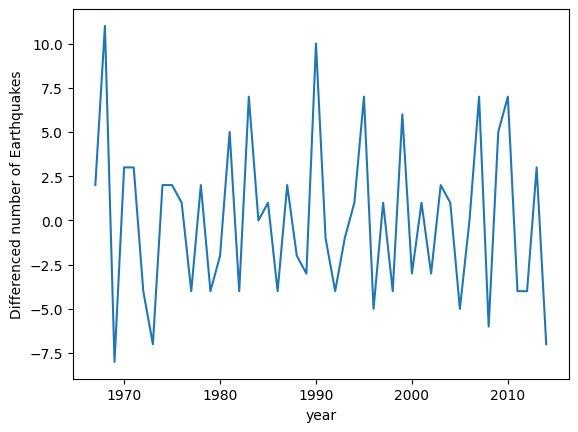

In [14]:
# Difference the data
differenced_data = earthquakes_per_year.diff().dropna()
# Plot the differenced data
ax = differenced_data.plot()
ax.set_ylabel('Differenced number of Earthquakes')
plt.show()

Notice the trend is removed. We can run the ADH on the differencing_data to check.

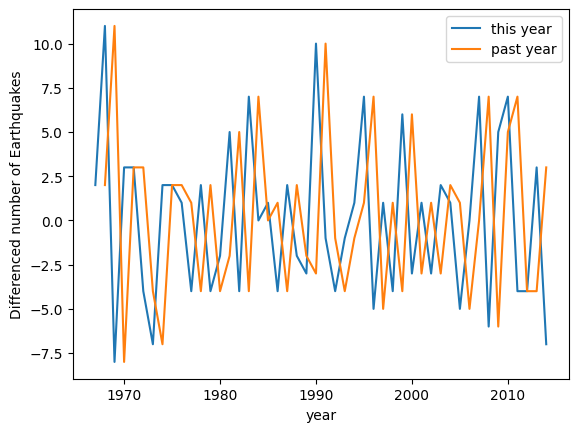

,this year,past year
this year,1.000000,-0.376859
past year,-0.376859,1.000000


In [15]:
## Autocorrelation of the differenced data

shifts_diff = pd.DataFrame(
{
'this year': differenced_data,
'past year': differenced_data.shift(1)
}
)
ax = shifts_diff.plot()
ax.set_ylabel('Differenced number of Earthquakes')
plt.show()
shifts_diff.corr()

We now obtain a correlation coefficient of -0.37, as can be seen in Figure 3-6: we 
have successfully removed the trend from the data. The correlation is now the negative 
correlation that we expected. If there are more earthquakes one year, then we generally 
have fewer earthquakes the next year.

### Lags in Autocorrelation

The number of lags of an autocorrelation means the number of steps back in time 
that have an impact on the present value. In many cases, if autocorrelation is present, it 
is not just the previous time step that has an impact, but it can be many time steps.

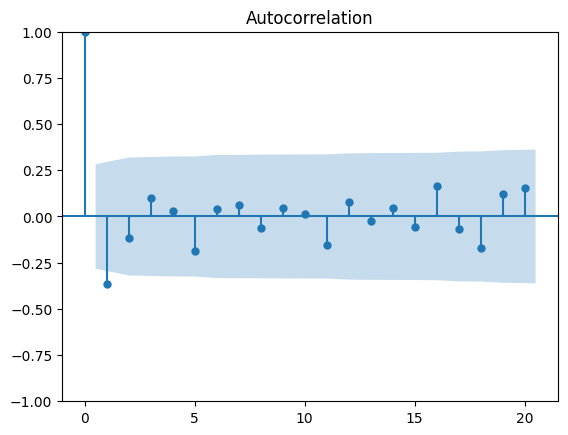

In [16]:
# Autocorrelation of the differenced data
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
plot_acf(differenced_data, lags=20) ## acf is short for autocorrelation function
plt.show()

This plot shows which autocorrelations are 
important to retain. On the y-axis, you see the correlation coefficient between the non- 
lagged data (original data) and the lagged data. The correlation coefficient is between -1 
and 1. On the x-axis, you see the number of lags applied, in this case from 0 to 20. The 
first correlation is 1, as this is the data with 0 lag: the original data.

The blue area in the graph allows you to detect visually which autocorrelations are 
just noise: if the spike goes outside of the blue area, there is a significant autocorrelation, 
but if the spike stays within the blue area, the observed autocorrelation is insignificant. 
You can generally expect the autocorrelation to be higher in lags that are closer to the 
present and diminish toward further-away moments.

You observe a first spike (at lag 0), which is very strong. 
This is normal, as it is the original data. The correlation between a variable and 
itself is always 1 (100%). The second spike is the correlation with lag 1. This is the 
autocorrelation that you have computed before using the correlation matrix. The 
correlation coefficient was -0.37, and you see this again in this graph.


### Partial Autocorrelation
The difference between autocorrelation and partial autocorrelation is that partial 
autocorrelation makes sure that any correlation is not counted multiple times 
for multiple lags.

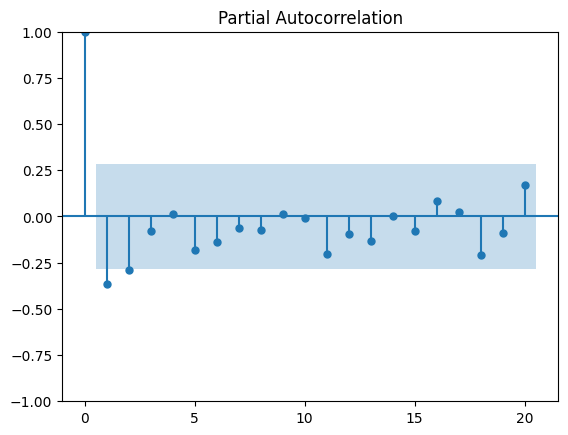

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(differenced_data, lags = 20)
plt.show()

As you can see based on the 
blue background shading in the graph, the PACF shows the first and the second lag 
outside of the shaded area. This means that it would be interesting to also include the 
second lag in the AR model

### Estimating the AR Using Yule-Walker Equations

In [20]:
# Estimate Yule-Walker AR coefficients with order 3
from statsmodels.regression.linear_model import yule_walker

coefficients, sigma = yule_walker(differenced_data, order = 3)

print('coefficients: ', -coefficients)
print('sigma: ', sigma)

coefficients:  [0.51636104 0.34981679 0.08922855]
sigma:  3.99051873543974


The coefficients that you obtain with this are the coefficients for each of the lagged 
variables. In this case, the order is 3, so that will need to be applied for the three last 
values to compute the new value. You can make a forecast by computing the next steps, 
based on the current coefficients. 

The more steps forward you want to forecast, the more difficult it becomes – your error 
will likely increase with the number of steps.

val_list:  [2.0, 11.0, -8.0, 3.0, 3.0, -4.0, -7.0, 2.0, 2.0, 1.0, -4.0, 2.0, -4.0, -2.0, 5.0, -4.0, 7.0, 0.0, 1.0, -4.0, 2.0, -2.0, -3.0, 10.0, -1.0, -4.0, -1.0, 1.0, 7.0, -5.0, 1.0, -4.0, 6.0, -3.0, 1.0, -3.0, 2.0, 1.0, -5.0, 0.0, 7.0, -6.0, 5.0, 7.0, -4.0, -4.0, 3.0, -7.0]
reverse_val_list:  [-7.0, 3.0, -4.0, -4.0, 7.0, 5.0, -6.0, 7.0, 0.0, -5.0, 1.0, 2.0, -3.0, 1.0, -3.0, 6.0, -4.0, 1.0, -5.0, 7.0, 1.0, -1.0, -4.0, -1.0, 10.0, -3.0, -2.0, 2.0, -4.0, 1.0, 0.0, 7.0, -4.0, 5.0, -2.0, -4.0, 2.0, -4.0, 1.0, 2.0, 2.0, -7.0, -4.0, 3.0, 3.0, -8.0, 11.0, 2.0]
3.614527253184987
2.5650768777712996
2.92199108265238
val_list with new_val 2.92199108265238
-1.5088023431157904
0.9399151995161465
0.6722295458553365
val_list with new_val 0.6722295458553365
-0.34711314484146866
-1.3692746910564642
-0.7446748325145738
val_list with new_val -0.7446748325145738
0.38452106812641323
0.14936388503906145
-0.11136114594455876
val_list with new_val -0.11136114594455876
0.0575025567089312
0.3180023175567792
0.2

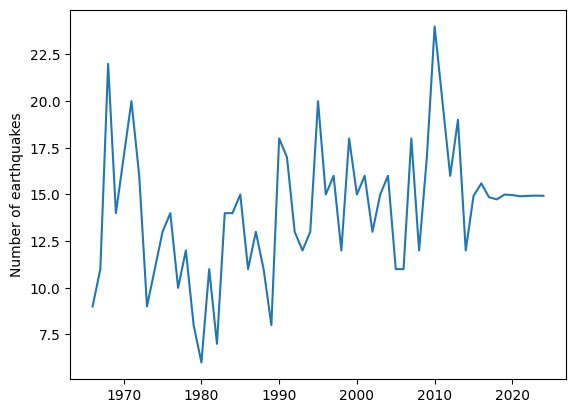

In [22]:
# Make a list of differenced values
val_list = list(differenced_data)
print('val_list: ',val_list)

#  Reverse the list so that the order corresponds with the order of the coefficients
val_list.reverse()
print('reverse_val_list: ', val_list) ## reversed so we can work with the more resent years

# Define the number of years to predict
n_steps = 10

# For each year to predict
for i in range(n_steps):
    # Compute the new value as the sum of lagged values multiplied by their corresponding coefficient
    new_val = 0

    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j] ## here we are simply calculating the predicted value based on the model (pred = 0.51636104X1 + 0.34981679X2 + 0.08922855X3. Remember x1, x2, x3 are the lags1, lags2, lags3
        print(new_val)

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val) ## Tis adds the predicted value to the start of the list as the next year's prediction
    print('val_list with new_val', new_val)

# Redo the reverse to have the order of time
val_list.reverse()
print('returned val_list: ',val_list) ## returns the order back to older years to recent years

## Remember these are the predicted differencing. Below will give us the original value

#  Add the original first value back into the list and do a cumulative sum to undo the differencing
val_list = [earthquakes_per_year.values[0]] + val_list
print('cum val_list',val_list)
new_val_list = pd.Series(val_list).cumsum()

# Plot the newly obtained list
plt.plot(range(1966, 2025), new_val_list)
plt.ylabel('Number of earthquakes')
plt.show()

The first values are actual data, and the last ten 
steps are forecasted data. Unfortunately, we can see that the model has not captured 
anything interesting: it is just a flat line!. Let’s try with an 
order of 20 this time and see whether anything improves.

In [23]:
coefficients, sigma = yule_walker(differenced_data, order = 20)

print('coefficients: ', -coefficients)
print('sigma: ', sigma)

coefficients:  [ 0.68210038  0.43671608  0.32622505  0.37607963  0.58250524  0.62416276
  0.52116694  0.45871818  0.30395538  0.42149383  0.61219884  0.49615822
  0.47069342  0.19908551  0.15957736  0.11795781  0.27713538  0.4186792
  0.07111315 -0.27725021]
sigma:  2.9246606275568117


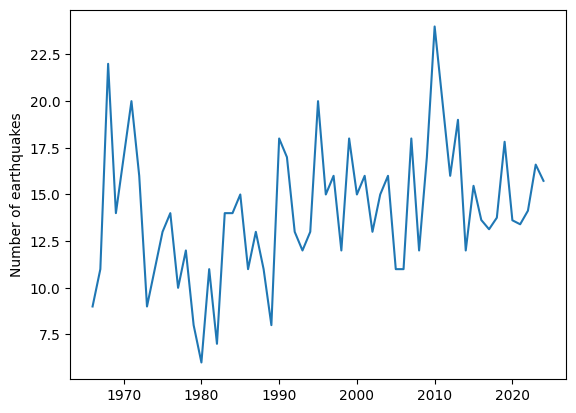

In [24]:
# Make a list of differenced values
val_list = list(differenced_data)
# print('val_list: ',val_list)

#  Reverse the list so that the order corresponds with the order of the coefficients
val_list.reverse()
# print('reverse_val_list: ', val_list) ## reversed so we can work with the more resent years

# Define the number of years to predict
n_steps = 10

# For each year to predict
for i in range(n_steps):
    # Compute the new value as the sum of lagged values multiplied by their corresponding coefficient
    new_val = 0

    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j] ## here we are simply calculating the predicted value based on the model
        # print(new_val)

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val) ## Tis adds the predicted value to the start of the list as the next year's prediction
    # print('val_list with new_val', new_val)

# Redo the reverse to have the order of time
val_list.reverse()
# print('returned val_list: ',val_list) ## returns the order back to older years to recent years

## Remember these are the predicted differencing. Below will give us the original value

#  Add the original first value back into the list and do a cumulative sum to undo the differencing
val_list = [earthquakes_per_year.values[0]] + val_list
# print('cum val_list',val_list)
new_val_list = pd.Series(val_list).cumsum()

# Plot the newly obtained list
plt.plot(range(1966, 2025), new_val_list)
plt.ylabel('Number of earthquakes')
plt.show()

Our model seems to be 
learning something much more interesting when we add an order 20: it has captured 
some variation.
Although this seems to fit well with the data visually, we still need to verify whether 
the model was correct: did it forecast something close to reality?


let’s apply a train-test split. We will cut off the last 10 years of the dataset 
and use them as a test set. This allows us to fit our model using the rest of the data (the 
train set). Once we have fitted on the train set, we can compute the error between the 
test set and our prediction

Test R2: -0.040346700807336155


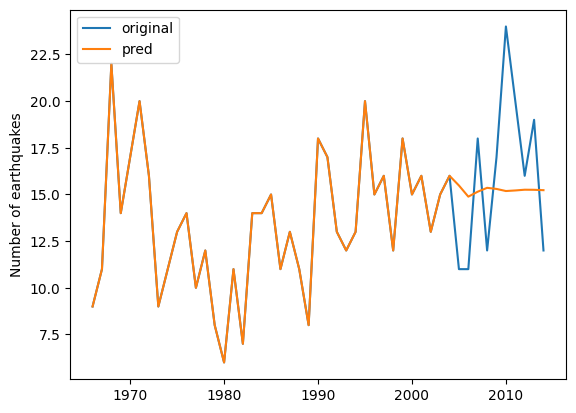

In [26]:
## Fit the model on a train set and evaluate it on a test set
from sklearn.metrics import r2_score

train = list(differenced_data)[:-10]
test = list(earthquakes_per_year)[-10:]

coefficients, sigma = yule_walker(train, order = 3)

# Make a list of differenced values
val_list = list(train)

#  Reverse the list so that the order corresponds with the order of the coefficients
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each year to predict
for i in range(n_steps):
    #  Compute the new value as the sum of lagged values multiplied by their corresponding coefficient
    new_val = 0
    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverso to have the order of time
val_list.reverse()

#  Add the original first value back into the list and do a cumulative sum to undo the differencing
val_list = [earthquakes_per_year.values[0]] + val_list
new_val_list = pd.Series(val_list).cumsum()

# Plot the newly obtained list
validation = pd.DataFrame({
'original': earthquakes_per_year.reset_index(drop=True),
'pred': new_val_list })
print('Test R2:', r2_score(validation.iloc[-10:, 0], validation.iloc[-10:, 1]))

# Plot the newly obtained list
plt.plot(range(1966, 2015), validation)
plt.legend(validation.columns)
plt.ylabel('Number of earthquakes')
plt.show()

The model with order 3 is quite bad. So bad that the R2 is negative  
(-0.04). You can see from the graph that the model suffers from 
underfitting: it did not capture anything and predicts only an average value into the 
future.

Obviously degree 20 was better. We will use `grid search` to identify the best degree.

In [29]:
# Apply a grid search to find the order that gives the best R2 score on the test data

def evaluate(order):
    train = list(differenced_data)[:-10]
    test = list(earthquakes_per_year)[-10:]

    coefficients, sigma = yule_walker(train, order = order)

    # Make a list of differenced values
    val_list = list(train)

    # Reverse the list to corresponds with the order of coefs
    val_list.reverse()

    # Define the number of years to predict
    n_steps = 10

    # For each year to predict
    for i in range(n_steps):
        # Compute the new value
        new_val = 0
        for j in range(len(coefficients)):
            new_val += coefficients[j] * val_list[j]

        # Insert the new value at the beginning of the list
        val_list.insert(0, new_val)

    # Redo the reverse to have the order of time
    val_list.reverse()

    # Undo the differencing with a cumsum
    val_list = [earthquakes_per_year.values[0]] + val_list
    new_val_list = pd.Series(val_list).cumsum()

    # Plot the newly obtained list
    validation = pd.DataFrame({
        'original': earthquakes_per_year.reset_index(drop=True),
        'pred': new_val_list 
    })

    return r2_score(validation.iloc[-10:, 0], validation.iloc[-10:, 1])



In [30]:
# For each order between 1 and 30, fit and evaluate the model
orders = []
r2scores = []
for order in range(1, 31):
    orders.append(order)
    r2scores.append(evaluate(order))

# Create a results data frame
results =pd.DataFrame({'orders': orders,'scores': r2scores})

# Show the order with best R2 score
results[results['scores'] == results.max()['scores']]

,orders,scores
18,19,0.133872


Notice order 19 has the highest R2_score.

Let us visualize it.

Test R2: 0.1338715328132326


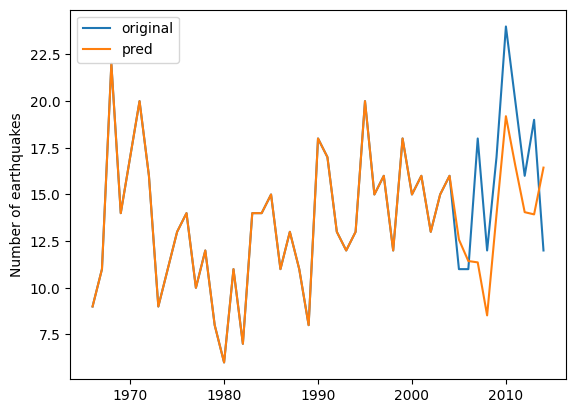

In [31]:
## Fit the model on a train set and evaluate it on a test set
from sklearn.metrics import r2_score

train = list(differenced_data)[:-10]
test = list(earthquakes_per_year)[-10:]

coefficients, sigma = yule_walker(train, order = 19)

# Make a list of differenced values
val_list = list(train)

#  Reverse the list so that the order corresponds with the order of the coefficients
val_list.reverse()

# Define the number of years to predict
n_steps = 10

# For each year to predict
for i in range(n_steps):
    #  Compute the new value as the sum of lagged values multiplied by their corresponding coefficient
    new_val = 0
    for j in range(len(coefficients)):
        new_val += coefficients[j] * val_list[j]

    # Insert the new value at the beginning of the list
    val_list.insert(0, new_val)

# Redo the reverso to have the order of time
val_list.reverse()

#  Add the original first value back into the list and do a cumulative sum to undo the differencing
val_list = [earthquakes_per_year.values[0]] + val_list
new_val_list = pd.Series(val_list).cumsum()

# Plot the newly obtained list
validation = pd.DataFrame({
'original': earthquakes_per_year.reset_index(drop=True),
'pred': new_val_list })
print('Test R2:', r2_score(validation.iloc[-10:, 0], validation.iloc[-10:, 1]))

# Plot the newly obtained list
plt.plot(range(1966, 2015), validation)
plt.legend(validation.columns)
plt.ylabel('Number of earthquakes')
plt.show()

The AR model can 
be used as a stand-alone model only in very rare and specific cases. In this real-life 
example of predicting earthquakes, the R2 score of 0.13 is not very good: We can surely 
do much better by including other building blocks of univariate time series



### Key Takeaways
* The AR model predicts the future of a variable by leveraging 
correlations between a variable’s past and present values.
* Autocorrelation is correlation between a time series and its previous 
values.
* Partial autocorrelation is autocorrelation conditional on earlier lags: 
it prevents double counting correlations.
* The number of lags to include in the AR model can be based on 
theory (ACF and PACF plots) or can be determined by a grid search.
* A grid search consists of doing a model evaluation for each value of 
the hyperparameters of a model. This is an optimization method for 
the choice of hyperparameters.
* Hyperparameters are different from model coefficients. Model 
coefficients are optimized by a model, while hyperparameters 
are chosen by the modeler. Yet the model can use optimization 
techniques like a grid search to find the best hyperparameters.
* Yule-Walker equations are used to fit the AR model. Fitting the model 
means finding the coefficients of the model